# Pemetaan Lahan Sawah dan Non-Sawah dari Citra Sentinel-2

Notebook ini memandu proses klasifikasi tutupan lahan dari data sampel hingga peta hasil. Penjelasan ditulis per tahap agar arti data, metode, dan hasilnya lebih mudah diikuti.

**Hasil akhir:** evaluasi model dan prediksi kelas pada poligon sampel uji dalam GeoPackage.

## Alur singkat

1. Membaca dan memeriksa poligon sampel Sawah dan Non-Sawah.
2. Menentukan area kajian dan mengunduh komposit Sentinel-2.
3. Meninjau citra serta merangkum nilai spektral untuk setiap poligon.
4. Melatih Random Forest dan mengevaluasi prediksinya pada poligon uji.
5. Menyimpan hasil prediksi sebagai layer poligon.

> Jalankan sel dari atas ke bawah. Jika GeoTIFF yang sesuai sudah ada, notebook akan menggunakannya kembali. Jika belum ada, sel unduh akan meminta autentikasi Copernicus melalui browser dan memerlukan koneksi internet.

## 1. Persiapan lingkungan dan lokasi berkas

Notebook mencari arsip `SAWAH.zip` dan `Non_SAWAH.zip` dari folder proyek atau folder induknya. Hasil citra, visualisasi evaluasi, peta poligon, dan GeoPackage prediksi disimpan di `Tugas/polutan/`.

Pastikan seluruh pustaka pada `requirements.txt` sudah terpasang sebelum menjalankan notebook.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib.patches import Patch
from rasterio.mask import mask
from shapely.geometry import box
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "SAWAH.zip").is_file()
        and (candidate / "Non_SAWAH.zip").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Arsip SAWAH.zip dan Non_SAWAH.zip tidak ditemukan. "
        "Simpan keduanya di folder proyek."
    )

RESULT_DIR = PROJECT_ROOT / "Tugas" / "polutan"
if not RESULT_DIR.is_dir():
    raise FileNotFoundError(f"Folder hasil tidak ditemukan: {RESULT_DIR}")

SAWAH_PATH = PROJECT_ROOT / "SAWAH.zip"
NON_SAWAH_PATH = PROJECT_ROOT / "Non_SAWAH.zip"
RASTER_NAME = "sentinel2_sawah_nonsawah.tif"
RASTER_CANDIDATES = [RESULT_DIR / RASTER_NAME, PROJECT_ROOT / RASTER_NAME]
OUTPUT_PATH = next(
    (candidate for candidate in RASTER_CANDIDATES if candidate.is_file()),
    RESULT_DIR / RASTER_NAME,
)

print(f"Folder proyek : {PROJECT_ROOT}")
print(f"Folder hasil  : {RESULT_DIR}")
print(f"Citra Sentinel-2: {OUTPUT_PATH}")
print(f"Arsip sampel tersedia: {SAWAH_PATH.is_file()} dan {NON_SAWAH_PATH.is_file()}")

Folder proyek : d:\SEMESTER 5\PSD\TUGAS
Folder hasil  : d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan
Citra Sentinel-2: d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\sentinel2_sawah_nonsawah.tif
Arsip sampel tersedia: True dan True


## 2. Memeriksa data sampel (ground truth)

Ground truth adalah contoh lokasi yang kelasnya sudah diketahui. Pada notebook ini, setiap poligon dari `SAWAH.zip` diberi label **Sawah (1)** dan setiap poligon dari `Non_SAWAH.zip` diberi label **Non-Sawah (0)**.

Poligon harus memiliki sistem koordinat (CRS) dan geometri yang valid. Semua geometri diseragamkan ke EPSG:4326 untuk menentukan area permintaan citra. Perbaikan hanya diterapkan pada geometri yang ditandai tidak valid.

In [2]:
def load_samples(path, class_name, class_id):
    if not path.is_file():
        raise FileNotFoundError(f"Arsip sampel tidak ditemukan: {path}")

    samples = gpd.read_file(path)
    if samples.empty:
        raise ValueError(f"Arsip tidak memiliki fitur: {path.name}")
    if samples.crs is None:
        raise ValueError(f"CRS tidak diketahui pada {path.name}.")
    if samples.geometry.isna().any() or samples.geometry.is_empty.any():
        raise ValueError(f"Ada geometri kosong pada {path.name}.")

    samples = samples.to_crs("EPSG:4326")
    invalid = ~samples.geometry.is_valid
    if invalid.any():
        print(f"Memperbaiki {int(invalid.sum())} geometri di {path.name}.")
        samples.loc[invalid, "geometry"] = samples.loc[invalid].geometry.make_valid()
    if (~samples.geometry.is_valid).any():
        raise ValueError(f"Masih ada geometri tidak valid pada {path.name}.")

    samples["kelas"] = class_name
    samples["label"] = class_id
    return samples


gdf_sawah = load_samples(SAWAH_PATH, "Sawah", 1)
gdf_nonsawah = load_samples(NON_SAWAH_PATH, "Non-Sawah", 0)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_nonsawah, gdf_sawah], ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326",
)

jumlah_per_kelas = (
    gdf_gabungan.groupby(["label", "kelas"])
    .size()
    .rename("Jumlah poligon")
    .reset_index()
)
print(f"Jumlah seluruh sampel: {len(gdf_gabungan)} poligon")
display(jumlah_per_kelas)
display(gdf_gabungan[["FID", "kelas", "label"]].head(8))

Memperbaiki 1 geometri di SAWAH.zip.
Jumlah seluruh sampel: 100 poligon


,label,kelas,Jumlah poligon
0,0,Non-Sawah,50
1,1,Sawah,50


,FID,kelas,label
0,0,Non-Sawah,0
1,1,Non-Sawah,0
2,2,Non-Sawah,0
3,3,Non-Sawah,0
4,4,Non-Sawah,0
5,5,Non-Sawah,0
6,6,Non-Sawah,0
7,7,Non-Sawah,0


### Sebaran dan keseimbangan sampel

Grafik kiri menunjukkan jumlah poligon per kelas. Peta kanan memperlihatkan lokasi poligon yang akan menjadi contoh pelatihan dan pengujian. Peta ini adalah sebaran **sampel**, bukan peta tutupan lahan hasil klasifikasi.

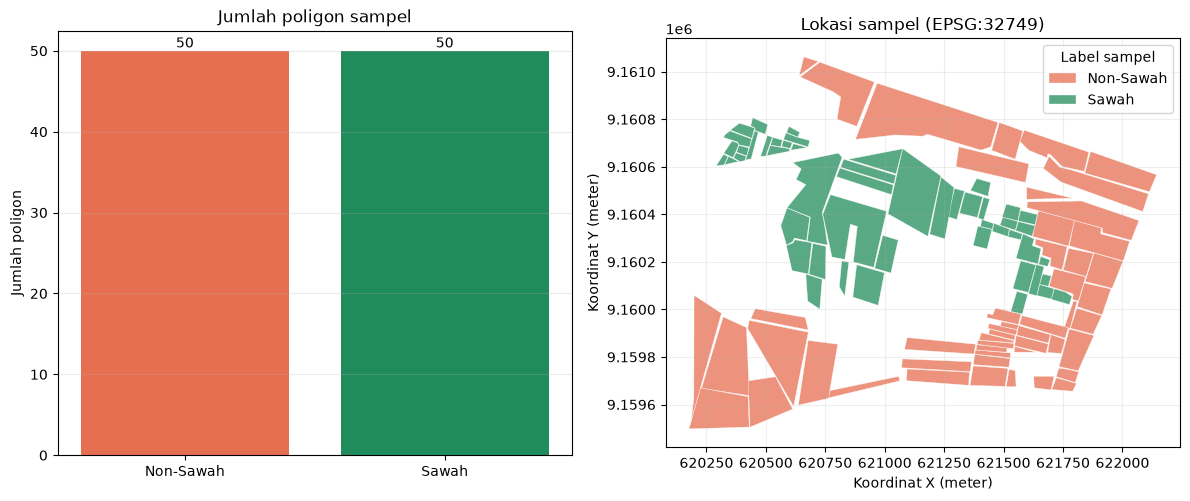

In [4]:
CLASS_COLORS = {"Non-Sawah": "#e76f51", "Sawah": "#218c5b"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = gdf_gabungan["kelas"].value_counts().reindex(
    ["Non-Sawah", "Sawah"], fill_value=0
)
axes[0].bar(
    counts.index,
    counts.values,
    color=[CLASS_COLORS[name] for name in counts.index],
)
axes[0].set_title("Jumlah poligon sampel")
axes[0].set_ylabel("Jumlah poligon")
axes[0].grid(axis="y", alpha=0.25)
for index, count in enumerate(counts.values):
    axes[0].text(index, count, str(count), ha="center", va="bottom")

samples_utm = gdf_gabungan.to_crs("EPSG:32749")
for class_name, color in CLASS_COLORS.items():
    samples_utm[samples_utm["kelas"] == class_name].plot(
        ax=axes[1],
        color=color,
        edgecolor="white",
        linewidth=0.35,
        alpha=0.75,
        label=class_name,
    )
axes[1].set_title("Lokasi sampel (EPSG:32749)")
axes[1].set_xlabel("Koordinat X (meter)")
axes[1].set_ylabel("Koordinat Y (meter)")
axes[1].set_aspect("equal")
axes[1].legend(title="Label sampel")
axes[1].grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 3. Menetapkan area kajian

openEO menerima batas area dalam koordinat geografis. Agar buffer benar-benar berukuran **500 meter**, batas sampel terlebih dahulu dihitung dalam EPSG:32749 (UTM zona 49S), lalu dibuat kotak pembatas dengan tambahan 500 meter di setiap sisi.

Kotak ini mencakup seluruh sampel dan area sekitarnya; bentuknya bukan hasil buffer individual setiap poligon.

,Batas area,Koordinat (EPSG:4326)
0,Barat,112.084868
1,Selatan,-7.607009
2,Timur,112.111821
3,Utara,-7.583746


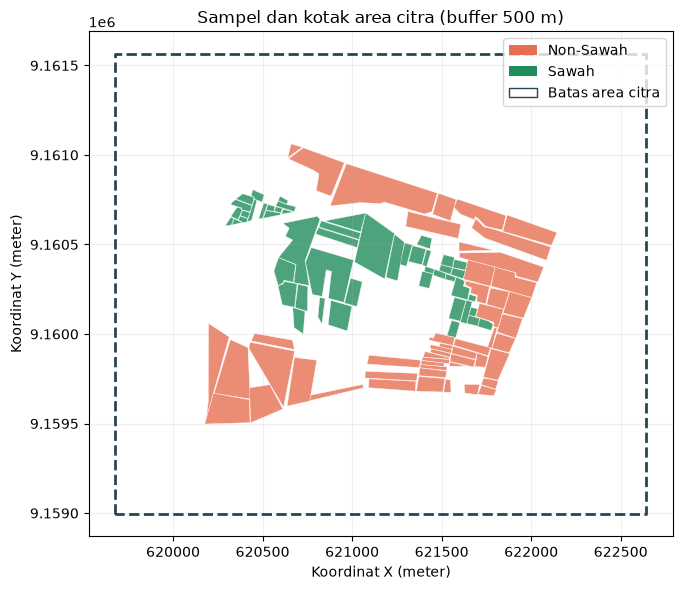

In [5]:
samples_utm = gdf_gabungan.to_crs("EPSG:32749")
min_x, min_y, max_x, max_y = samples_utm.total_bounds
buffer_m = 500

extent_utm = box(
    min_x - buffer_m,
    min_y - buffer_m,
    max_x + buffer_m,
    max_y + buffer_m,
)
extent_wgs84 = (
    gpd.GeoSeries([extent_utm], crs="EPSG:32749")
    .to_crs("EPSG:4326")
    .iloc[0]
)
west, south, east, north = extent_wgs84.bounds
bbox = {
    "west": float(west),
    "south": float(south),
    "east": float(east),
    "north": float(north),
}

display(
    pd.DataFrame(
        {
            "Batas area": ["Barat", "Selatan", "Timur", "Utara"],
            "Koordinat (EPSG:4326)": [west, south, east, north],
        }
    ).round(6)
)

fig, ax = plt.subplots(figsize=(8, 6))
for class_name, color in CLASS_COLORS.items():
    samples_utm[samples_utm["kelas"] == class_name].plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.35,
        alpha=0.8,
    )
gpd.GeoSeries([extent_utm], crs="EPSG:32749").boundary.plot(
    ax=ax, color="#264653", linewidth=2, linestyle="--"
)
ax.set_title("Sampel dan kotak area citra (buffer 500 m)")
ax.set_xlabel("Koordinat X (meter)")
ax.set_ylabel("Koordinat Y (meter)")
ax.set_aspect("equal")
ax.legend(
    handles=[
        Patch(facecolor=CLASS_COLORS[name], label=name)
        for name in ("Non-Sawah", "Sawah")
    ]
    + [Patch(facecolor="none", edgecolor="#264653", label="Batas area citra")],
    loc="best",
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 4. Mengambil komposit Sentinel-2 L2A

Permintaan citra memakai rentang **1 Mei–30 September 2026**, dengan awan maksimum **10%**. Komposit median waktu merangkum pengamatan yang tersedia selama rentang tanggal tersebut menjadi satu nilai per piksel.

| Band | Panjang gelombang / kegunaan umum |
|---|---|
| B02 | Biru; membantu membedakan air dan permukaan |
| B03 | Hijau; tampilan warna alami |
| B04 | Merah; tampilan warna alami dan indeks vegetasi |
| B08 | Inframerah dekat; peka terhadap vegetasi |
| B11 | Inframerah gelombang pendek; peka terhadap kelembapan dan permukaan terbangun |

Jika berkas GeoTIFF sudah ada, proses autentikasi dan unduhan dilewati. Jika belum, notebook mengirim permintaan ke Copernicus melalui openEO.

In [6]:
if OUTPUT_PATH.is_file():
    print(f"Menggunakan citra yang sudah tersedia: {OUTPUT_PATH}")
else:
    import openeo

    connection = openeo.connect(
        "openeo.dataspace.copernicus.eu"
    ).authenticate_oidc()
    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=["2026-05-01", "2026-09-30"],
        bands=["B02", "B03", "B04", "B08", "B11"],
        max_cloud_cover=10,
    )
    composite_s2 = datacube.median_time()
    print(f"Mengunduh citra ke: {OUTPUT_PATH}")
    composite_s2.download(str(OUTPUT_PATH), format="GTiff")
    if not OUTPUT_PATH.is_file():
        raise FileNotFoundError(f"Unduhan tidak menghasilkan berkas: {OUTPUT_PATH}")
    print("Unduhan citra selesai.")

Menggunakan citra yang sudah tersedia: d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\sentinel2_sawah_nonsawah.tif


## 5. Memeriksa citra dan melihat warna alami

Sebelum melatih model, periksa ukuran, CRS, band, dan nilai nodata citra. Pratinjau berikut menyusun **B04 (merah), B03 (hijau), dan B02 (biru)** menjadi komposit warna alami. Kontras diregangkan dengan persentil 2–98 hanya untuk tampilan; nilai raster untuk klasifikasi tidak diubah oleh peregangan ini.

Garis berwarna menunjukkan batas poligon sampel di atas citra.

,Properti,Nilai
0,Lebar × tinggi,299 × 259
1,Jumlah band,5
2,Resolusi piksel (meter),10 × 10
3,CRS,EPSG:32749
4,Nilai nodata,-32768.0
5,Nama band,"B02, B03, B04, B08, B11"


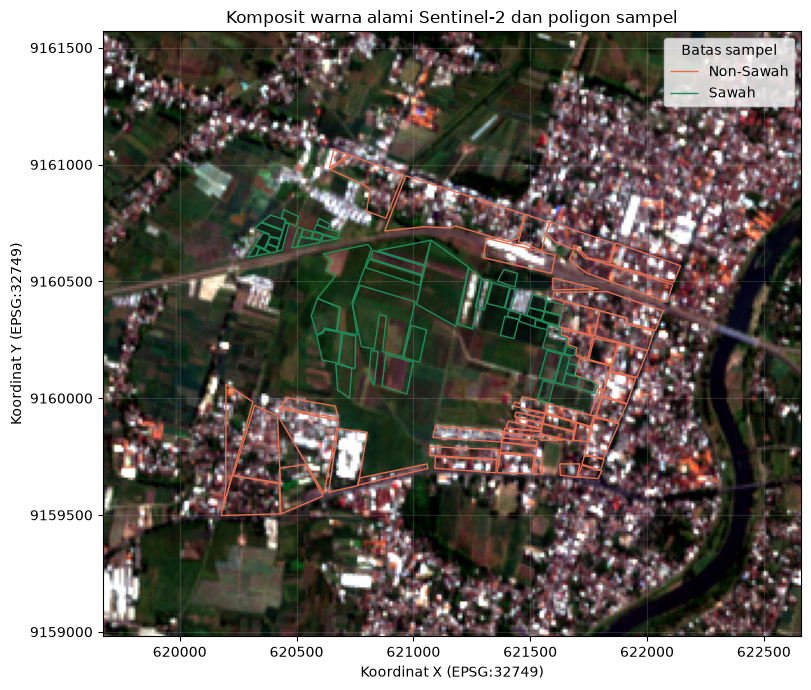

In [7]:
BAND_NAMES = ["B02", "B03", "B04", "B08", "B11"]

with rasterio.open(OUTPUT_PATH) as src:
    if src.count != len(BAND_NAMES):
        raise ValueError(
            f"Citra harus memiliki {len(BAND_NAMES)} band; ditemukan {src.count}."
        )
    if src.crs is None:
        raise ValueError("CRS citra tidak diketahui.")

    raster_crs = src.crs
    raster_bounds = src.bounds
    rgb_bands = src.read([3, 2, 1], masked=True).astype(np.float32).filled(np.nan)
    raster_valid_rgb = np.isfinite(rgb_bands).all(axis=0)
    if not raster_valid_rgb.any():
        raise ValueError("Citra tidak memiliki piksel valid untuk pratinjau.")

    rgb = np.zeros((*raster_valid_rgb.shape, 3), dtype=np.float32)
    for channel in range(3):
        values = rgb_bands[channel][raster_valid_rgb]
        low, high = np.nanpercentile(values, [2, 98])
        if high <= low:
            high = low + 1
        rgb[:, :, channel] = np.clip(
            (rgb_bands[channel] - low) / (high - low), 0, 1
        )
    rgb[~raster_valid_rgb] = 1

    raster_info = pd.DataFrame(
        {
            "Properti": [
                "Lebar × tinggi",
                "Jumlah band",
                "Resolusi piksel (meter)",
                "CRS",
                "Nilai nodata",
                "Nama band",
            ],
            "Nilai": [
                f"{src.width} × {src.height}",
                src.count,
                f"{abs(src.res[0]):g} × {abs(src.res[1]):g}",
                str(src.crs),
                src.nodata,
                ", ".join(BAND_NAMES),
            ],
        }
    )
    raster_extent = (
        raster_bounds.left,
        raster_bounds.right,
        raster_bounds.bottom,
        raster_bounds.top,
    )

display(raster_info)
samples_in_raster_crs = gdf_gabungan.to_crs(raster_crs)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(rgb, extent=raster_extent, origin="upper")
for class_name, color in CLASS_COLORS.items():
    samples_in_raster_crs[samples_in_raster_crs["kelas"] == class_name].boundary.plot(
        ax=ax, color=color, linewidth=1, label=class_name
    )
ax.set_title("Komposit warna alami Sentinel-2 dan poligon sampel")
ax.set_xlabel(f"Koordinat X ({raster_crs})")
ax.set_ylabel(f"Koordinat Y ({raster_crs})")
ax.ticklabel_format(style="plain", useOffset=False)
ax.legend(title="Batas sampel")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 6. Membentuk fitur spektral untuk setiap sampel

Nilai rata-rata lima band di dalam setiap poligon menjadi fitur dasar. Empat indeks ditambahkan untuk menyoroti karakteristik yang berbeda.

| Fitur | Rumus | Interpretasi umum |
|---|---|---|
| NDVI | (B08 − B04) / (B08 + B04) | Respons vegetasi |
| NDMI | (B08 − B11) / (B08 + B11) | Kelembapan vegetasi/permukaan |
| NDBI | (B11 − B08) / (B11 + B08) | Permukaan terbangun |
| MNDWI | (B03 − B11) / (B03 + B11) | Air terbuka |

Lima nilai reflektansi dirata-ratakan di dalam setiap poligon terlebih dahulu. Empat indeks kemudian dihitung dari nilai rata-rata tersebut, sehingga satu baris fitur tetap mewakili satu poligon. Semua indeks berada pada rentang kurang lebih −1 sampai 1; penyebut nol ditangani agar hasil tetap terdefinisi.

In [8]:
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDMI", "NDBI", "MNDWI"]
LABEL_NAMES = ["Non-Sawah", "Sawah"]


def normalized_difference(first, second):
    denominator = first + second
    return np.divide(
        first - second,
        denominator,
        out=np.zeros_like(first, dtype=np.float32),
        where=np.abs(denominator) > 1e-6,
    )


def make_feature_stack(bands):
    bands = np.asarray(bands, dtype=np.float32)
    blue, green, red, nir, swir = bands
    return np.vstack(
        (
            bands,
            normalized_difference(nir, red),
            normalized_difference(nir, swir),
            normalized_difference(swir, nir),
            normalized_difference(green, swir),
        )
    )


features, labels, sample_ids = [], [], []
with rasterio.open(OUTPUT_PATH) as src:
    for _, sample in samples_in_raster_crs.iterrows():
        geometry = sample.geometry
        if not geometry.is_valid:
            geometry = geometry.make_valid()
        clipped, _ = mask(
            src, [geometry.__geo_interface__], crop=True, filled=False
        )
        pixel_bands = np.ma.asarray(clipped, dtype=np.float32).filled(np.nan)
        valid_pixels = np.isfinite(pixel_bands).all(axis=0)
        if not valid_pixels.any():
            raise ValueError(
                f"Poligon FID={sample['FID']} tidak menutupi piksel citra yang valid. "
                "Periksa kembali area unduhan dan posisi sampel."
            )

        mean_band_values = pixel_bands[:, valid_pixels].mean(axis=1)
        polygon_features = make_feature_stack(mean_band_values[:, None])
        features.append(polygon_features[:, 0])
        labels.append(int(sample["label"]))
        sample_ids.append(sample["FID"])

X = np.asarray(features, dtype=np.float32)
y = np.asarray(labels, dtype=np.uint8)
if not np.isfinite(X).all():
    raise ValueError("Fitur berisi nilai tak hingga atau NaN; periksa citra dan sampel.")
if len(np.unique(y)) != 2:
    raise ValueError("Kedua kelas Sawah dan Non-Sawah harus tersedia.")

feature_table = pd.DataFrame(X, columns=FEATURE_NAMES)
feature_table.insert(0, "kelas", [LABEL_NAMES[label] for label in y])
feature_table.insert(0, "FID", sample_ids)
print(f"Matriks fitur: {X.shape[0]} sampel × {X.shape[1]} fitur")
display(feature_table.head(10).round(4))

Matriks fitur: 100 sampel × 9 fitur


,FID,kelas,B02,B03,B04,B08,B11,NDVI,NDMI,NDBI,MNDWI
0,0,Non-Sawah,1102.081421,1217.081421,1284.903687,1904.889038,2364.636963,0.1944,-0.1077,0.1077,-0.3204
1,1,Non-Sawah,832.500000,970.181030,1094.663818,1933.784424,2292.068848,0.2771,-0.0848,0.0848,-0.4052
2,2,Non-Sawah,955.503601,1080.071899,1191.374146,2001.251831,2375.906494,0.2537,-0.0856,0.0856,-0.3750
3,3,Non-Sawah,1036.565186,1168.452148,1258.860840,2046.478149,2508.252197,0.2383,-0.1014,0.1014,-0.3644
4,4,Non-Sawah,925.559998,1087.520020,1293.880005,2026.719971,2451.479980,0.2207,-0.0949,0.0949,-0.3854
5,5,Non-Sawah,797.916687,951.500000,1040.099976,2129.050049,2288.449951,0.3436,-0.0361,0.0361,-0.4126
6,6,Non-Sawah,759.607117,884.857117,1018.678589,1902.678589,2311.142822,0.3026,-0.0969,0.0969,-0.4463
7,7,Non-Sawah,958.269226,1077.538452,1232.192261,1878.153809,2448.384521,0.2077,-0.1318,0.1318,-0.3888
8,8,Non-Sawah,852.517212,972.758606,1124.517212,1826.931030,2366.172363,0.2380,-0.1286,0.1286,-0.4173
9,9,Non-Sawah,748.032288,894.225830,984.419373,2043.032227,2443.161377,0.3497,-0.0892,0.0892,-0.4641


### Cara membaca tabel fitur

Setiap baris mewakili **satu poligon**, bukan satu piksel. Kolom `B02`–`B11` menyimpan rata-rata nilai reflektansi komposit di dalam poligon; kolom indeks dihitung dari rata-rata band tersebut. Besaran reflektansi dapat bergantung pada skala penyimpanan produk, sedangkan indeks ternormalisasi lebih mudah dibandingkan antarfitur.

In [9]:
feature_summary = (
    feature_table.groupby("kelas")[FEATURE_NAMES]
    .mean()
    .T.rename(columns={"Non-Sawah": "Rata-rata Non-Sawah", "Sawah": "Rata-rata Sawah"})
)
display(feature_summary.round(4))

kelas,Rata-rata Non-Sawah,Rata-rata Sawah
B02,903.663513,581.117004
B03,1046.970337,785.262207
B04,1138.060547,656.403381
B08,2049.132568,2793.031250
B11,2375.147461,1942.733154
NDVI,0.288700,0.617500
NDMI,-0.074000,0.177100
NDBI,0.074000,-0.177100
MNDWI,-0.391800,-0.424700


## 7. Melatih dan menguji Random Forest

Data dibagi secara **stratified**: 80% poligon untuk pelatihan dan 20% untuk pengujian, sambil mempertahankan proporsi kelas. `random_state=42` membuat pembagian dan model dapat diulang; 300 pohon digunakan untuk menggabungkan banyak aturan keputusan. Hasil prediksi peta pada bagian berikut hanya mencakup poligon uji yang tidak dipakai saat pelatihan.

Matriks `X_train` ditampilkan setelah pembagian data. Setiap baris adalah satu poligon pelatihan dan setiap kolom adalah fitur spektral; label kelas disimpan terpisah di `y_train`.

Pengujian di bawah ini memisahkan **poligon**, tetapi belum memakai pemisahan spasial berblok. Karena lokasi yang berdekatan dapat memiliki karakteristik serupa, skor pada pemisahan acak bisa lebih optimistis daripada kinerja di wilayah baru. Poligon uji adalah sampel evaluasi, bukan cakupan seluruh bidang di area kajian.

X_train: 80 poligon × 9 fitur


,FID,kelas,B02,B03,B04,B08,B11,NDVI,NDMI,NDBI,MNDWI
0,15,Non-Sawah,835.000000,991.400024,1015.818176,2237.272705,2117.018066,0.3755,0.0276,-0.0276,-0.3621
1,2,Sawah,650.944397,814.500000,682.055603,2507.777832,1984.666626,0.5724,0.1164,-0.1164,-0.4180
2,10,Sawah,480.222198,654.833313,466.111115,3036.666748,1861.000000,0.7339,0.2400,-0.2400,-0.4794
3,16,Sawah,683.291687,811.625000,701.833313,2596.791748,1980.375000,0.5745,0.1347,-0.1347,-0.4186
4,18,Sawah,498.149994,667.450012,504.200012,2821.875000,1822.449951,0.6968,0.2152,-0.2152,-0.4639
...,...,...,...,...,...,...,...,...,...,...,...
75,17,Non-Sawah,801.886780,978.452820,1025.358521,2428.962158,2293.528320,0.4063,0.0287,-0.0287,-0.4019
76,36,Non-Sawah,876.405273,991.119019,1130.462524,1751.008789,2406.836914,0.2154,-0.1577,0.1577,-0.4166
77,35,Sawah,538.555603,757.111084,539.111084,2598.222168,1833.777832,0.6563,0.1725,-0.1725,-0.4156
78,21,Non-Sawah,754.166687,858.027771,973.638916,1591.277832,1926.194458,0.2408,-0.0952,0.0952,-0.3836


Jumlah sampel latih : 80
Jumlah sampel uji   : 20
Akurasi data uji    : 100.0%


,precision,recall,f1-score,support
Non-Sawah,1.0,1.0,1.0,10.0
Sawah,1.0,1.0,1.0,10.0
macro avg,1.0,1.0,1.0,20.0
weighted avg,1.0,1.0,1.0,20.0


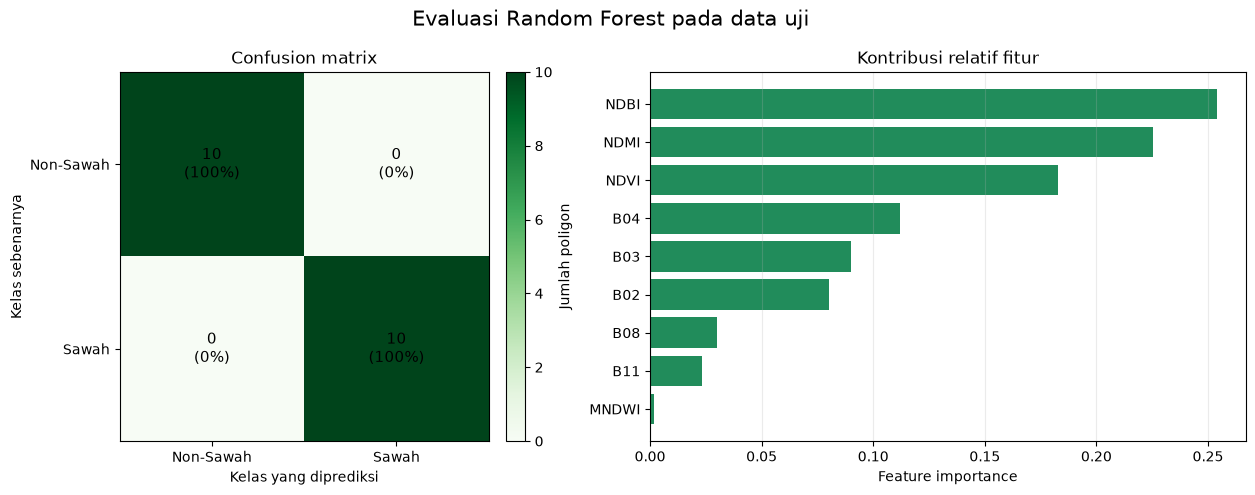

Visualisasi evaluasi disimpan: d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\evaluasi_klasifikasi_sawah_nonsawah.png


In [12]:
sample_indices = np.arange(len(y))
train_indices, test_indices = train_test_split(
    sample_indices,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

X_train_table = pd.DataFrame(X_train, columns=FEATURE_NAMES)
X_train_table.insert(0, "kelas", [LABEL_NAMES[label] for label in y_train])
X_train_table.insert(0, "FID", np.asarray(sample_ids)[train_indices])
print(f"X_train: {X_train.shape[0]} poligon × {X_train.shape[1]} fitur")
display(X_train_table.round(4))


model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
report = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

print(f"Jumlah sampel latih : {len(y_train)}")
print(f"Jumlah sampel uji   : {len(y_test)}")
print(f"Akurasi data uji    : {accuracy:.1%}")

metrics_table = pd.DataFrame(report).T.loc[
    LABEL_NAMES + ["macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"],
]
display(metrics_table.round(3))

fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.35]}
)
image = axes[0].imshow(matrix, cmap="Greens")
axes[0].set(
    title="Confusion matrix",
    xlabel="Kelas yang diprediksi",
    ylabel="Kelas sebenarnya",
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
for row in range(matrix.shape[0]):
    actual_total = matrix[row].sum()
    for column in range(matrix.shape[1]):
        row_percent = 100 * matrix[row, column] / actual_total if actual_total else 0
        axes[0].text(
            column,
            row,
            f"{matrix[row, column]}\n({row_percent:.0f}%)",
            ha="center",
            va="center",
            color="black",
            fontsize=11,
        )
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label="Jumlah poligon")

importance_order = np.argsort(model.feature_importances_)
axes[1].barh(
    np.array(FEATURE_NAMES)[importance_order],
    model.feature_importances_[importance_order],
    color="#218c5b",
)
axes[1].set_title("Kontribusi relatif fitur")
axes[1].set_xlabel("Feature importance")
axes[1].grid(axis="x", alpha=0.25)
fig.suptitle("Evaluasi Random Forest pada data uji", fontsize=15)
fig.tight_layout()
EVALUATION_PATH = RESULT_DIR / "evaluasi_klasifikasi_sawah_nonsawah.png"
fig.savefig(EVALUATION_PATH, dpi=180, bbox_inches="tight")
plt.show()
print(f"Visualisasi evaluasi disimpan: {EVALUATION_PATH}")

### Menafsirkan evaluasi

- **Confusion matrix:** baris adalah kelas sebenarnya; kolom adalah prediksi. Sel diagonal berarti prediksi benar, sedangkan sel di luar diagonal menunjukkan kekeliruan.
- **Precision:** dari semua prediksi untuk suatu kelas, berapa proporsi yang benar.
- **Recall:** dari semua sampel sebenarnya pada suatu kelas, berapa proporsi yang berhasil ditemukan.
- **F1-score:** ringkasan seimbang antara precision dan recall.
- **Feature importance:** menunjukkan seberapa sering fitur membantu pemisahan dalam model; ini bukan bukti sebab-akibat dan bukan ukuran kualitas data.

Jumlah sampel uji pada pekerjaan ini terbatas. Selalu lihat jumlah `support` bersama skor, dan hindari menganggap akurasi pada sampel yang sama sebagai jaminan kinerja di tempat atau waktu lain.

## 8. Menampilkan prediksi pada poligon uji

Model yang dilatih pada 80% poligon diterapkan pada seluruh 100 poligon sampel agar peta menampilkan semua geometri yang tersedia. GeoPackage menandai sampel latih dan uji; hanya 20 poligon uji yang digunakan untuk evaluasi akurasi. Luas pada tabel adalah luas geometri sampel menurut kelas prediksi, bukan estimasi cakupan seluruh wilayah.

Hasil disimpan sebagai GeoPackage agar geometri poligon, kelas sebenarnya, dan kelas prediksi dapat diperiksa kembali. Tidak ada klasifikasi seluruh piksel atau pembuatan GeoTIFF kelas.

,Kelas prediksi,jumlah_poligon,luas_poligon_sampel_ha
0,Non-Sawah,50,75.46
1,Sawah,50,36.47


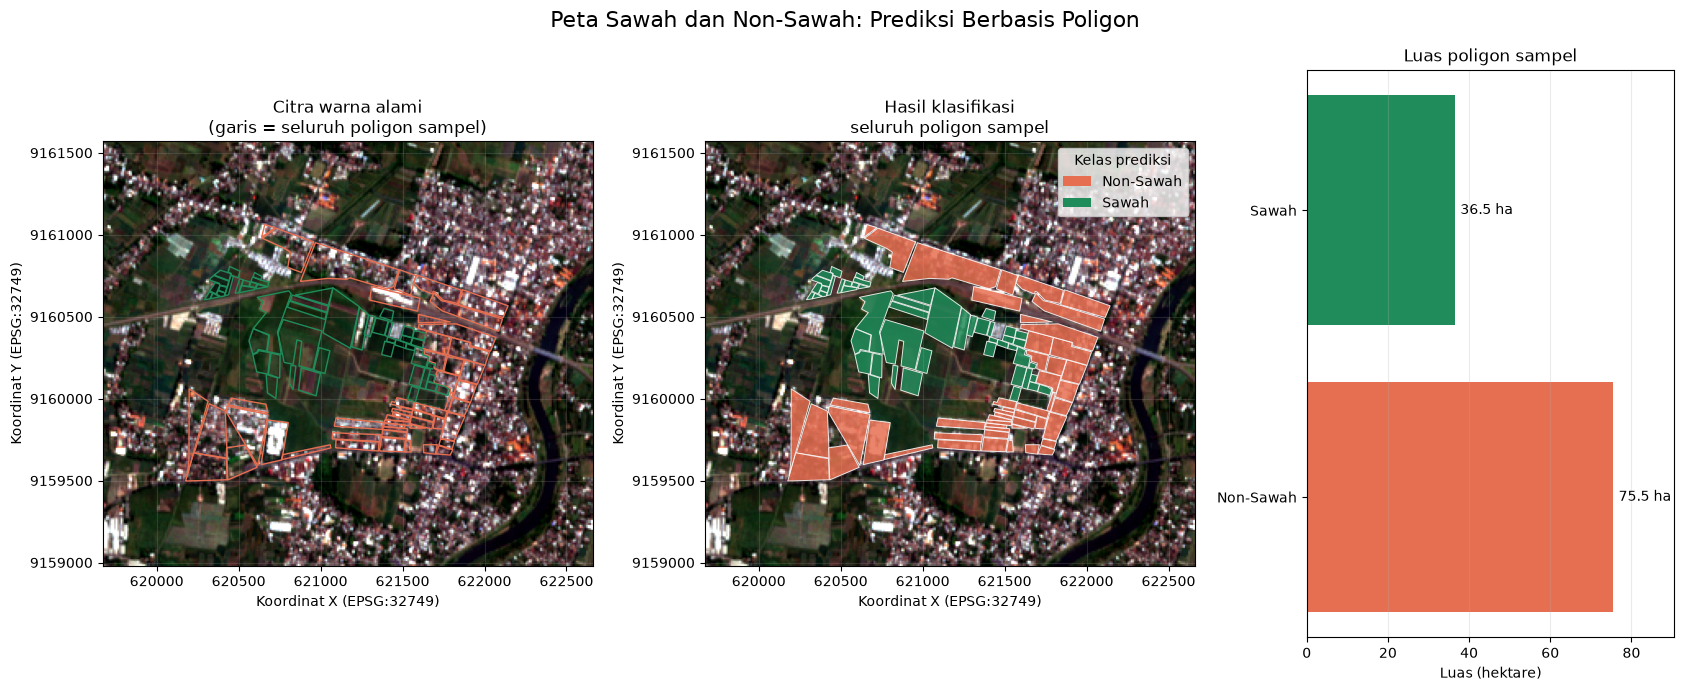

Peta poligon disimpan: d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\peta_klasifikasi_sawah_nonsawah.png
GeoPackage prediksi disimpan: d:\SEMESTER 5\PSD\TUGAS\Tugas\polutan\prediksi_poligon_sawah_nonsawah.gpkg
Jumlah poligon pada peta: 100
Poligon uji untuk evaluasi: 20


In [16]:
PREDICTIONS_PATH = RESULT_DIR / "prediksi_poligon_sawah_nonsawah.gpkg"
MAP_PATH = RESULT_DIR / "peta_klasifikasi_sawah_nonsawah.png"

all_predictions = model.predict(X)
all_polygons = samples_in_raster_crs.copy()
all_polygons["split"] = np.where(
    np.isin(np.arange(len(y)), test_indices), "uji", "latih"
)
all_polygons["label_prediksi"] = all_predictions
all_polygons["kelas_prediksi"] = [
    LABEL_NAMES[label] for label in all_predictions
]
all_polygons["prediksi_benar"] = all_predictions == y
all_polygons = all_polygons.rename(columns={"FID": "sample_id"})
all_polygons.to_file(
    PREDICTIONS_PATH,
    layer="prediksi_poligon",
    driver="GPKG",
)

all_polygons_utm = all_polygons.to_crs("EPSG:32749")
all_polygons_utm["luas_ha"] = all_polygons_utm.geometry.area / 10_000
area_table = (
    all_polygons_utm.groupby("kelas_prediksi")
    .agg(
        jumlah_poligon=("sample_id", "size"),
        luas_poligon_sampel_ha=("luas_ha", "sum"),
    )
    .reindex(LABEL_NAMES, fill_value=0)
    .rename_axis("Kelas prediksi")
    .reset_index()
)
display(area_table.round(2))

with rasterio.open(OUTPUT_PATH) as src:
    map_extent = (
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    )

fig, axes = plt.subplots(
    1, 3, figsize=(17, 7), gridspec_kw={"width_ratios": [1, 1, 0.75]}
)
for ax in axes[:2]:
    ax.imshow(rgb, extent=map_extent, origin="upper")
    ax.set_xlabel(f"Koordinat X ({raster_crs})")
    ax.set_ylabel(f"Koordinat Y ({raster_crs})")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.set_aspect("equal")
    ax.grid(alpha=0.18)

for class_name, color in CLASS_COLORS.items():
    samples_in_raster_crs[samples_in_raster_crs["kelas"] == class_name].boundary.plot(
        ax=axes[0], color=color, linewidth=1, label=class_name
    )
    all_polygons[all_polygons["kelas_prediksi"] == class_name].plot(
        ax=axes[1], color=color, edgecolor="white", linewidth=0.7, alpha=0.85
    )
axes[0].set_title("Citra warna alami\n(garis = seluruh poligon sampel)")
axes[1].set_title("Hasil klasifikasi\nseluruh poligon sampel")
axes[1].legend(
    handles=[
        Patch(facecolor=CLASS_COLORS[name], label=name)
        for name in ("Non-Sawah", "Sawah")
    ],
    title="Kelas prediksi",
    loc="best",
)
area_bars = axes[2].barh(
    area_table["Kelas prediksi"],
    area_table["luas_poligon_sampel_ha"],
    color=[CLASS_COLORS[name] for name in area_table["Kelas prediksi"]],
)
axes[2].bar_label(area_bars, fmt="%.1f ha", padding=4)
axes[2].set_title("Luas poligon sampel")
axes[2].set_xlabel("Luas (hektare)")
axes[2].set_xlim(0, area_table["luas_poligon_sampel_ha"].max() * 1.2)
axes[2].grid(axis="x", alpha=0.25)
fig.suptitle("Peta Sawah dan Non-Sawah: Prediksi Berbasis Poligon", fontsize=16)
fig.tight_layout()
fig.savefig(MAP_PATH, dpi=180, bbox_inches="tight")
plt.show()

print(f"Peta poligon disimpan: {MAP_PATH}")
print(f"GeoPackage prediksi disimpan: {PREDICTIONS_PATH}")
print(f"Jumlah poligon pada peta: {len(all_polygons)}")
print(f"Poligon uji untuk evaluasi: {len(test_indices)}")

## 9. Ringkasan dan batasan hasil

Notebook ini merangkum reflektansi Sentinel-2 dan empat indeks spektral per poligon, mengukur kinerja Random Forest pada data uji, lalu menyimpan prediksi kelas untuk poligon uji tersebut. Tidak dilakukan klasifikasi piksel atau pemetaan seluruh area.

**Berkas hasil** disimpan di folder `Tugas/polutan/`:

- `evaluasi_klasifikasi_sawah_nonsawah.png` — confusion matrix dan feature importance.
- `peta_klasifikasi_sawah_nonsawah.png` — komposit citra dan seluruh poligon sampel berwarna menurut kelas prediksi.
- `prediksi_poligon_sawah_nonsawah.gpkg` — seluruh geometri poligon sampel, kelas sebenarnya/prediksi, dan penanda latih/uji.

**Perhatian saat menggunakan hasil:** peta dan GeoPackage hanya mencakup poligon sampel yang tersedia, bukan seluruh persil di wilayah kajian. Prediksi pada poligon latih adalah hasil in-sample; akurasi model tetap dihitung terpisah dari 20 poligon uji. Luas merupakan jumlah luas geometri sampel per kelas prediksi dan jangan ditafsirkan sebagai luas total sawah/non-sawah di wilayah. Kualitas peta bergantung pada kebenaran label sampel, awan/no-data, resolusi, dan keterwakilan musim. Untuk klaim akurasi yang lebih kuat, gunakan sampel uji independen dan validasi spasial pada lokasi berbeda.